# Issue 5.2 — Result visualizations

Vier publication-quality figuren voor de fiche en defense:

1. Bar chart van **% calls answered** per agent (uit `results/eval_summary.csv`).
2. Heatmap **agent-coverage vs werkelijke vraag** per (zone × uur).
3. Tijdlijn van **alle karren in beweging** op één gesimuleerde dag (van-trajecten op kaart).
4. **Reward curves** per agent tijdens training (Q-learning + DQN, met baseline-lijnen).

In [1]:
import torch  # noqa: F401

import os, sys
from datetime import date
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    os.chdir(ROOT.parent)
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})
AGENT_COLORS = {
    'random': '#9c9c9c', 'greedy': '#ff7f0e', 'historical': '#2ca02c',
    'q_learning': '#1f77b4', 'dqn': '#d62728',
}
AGENT_ORDER = ['random', 'greedy', 'historical', 'q_learning', 'dqn']
print('setup OK')

setup OK


## Figuur 1 — Bar chart: % calls answered per agent

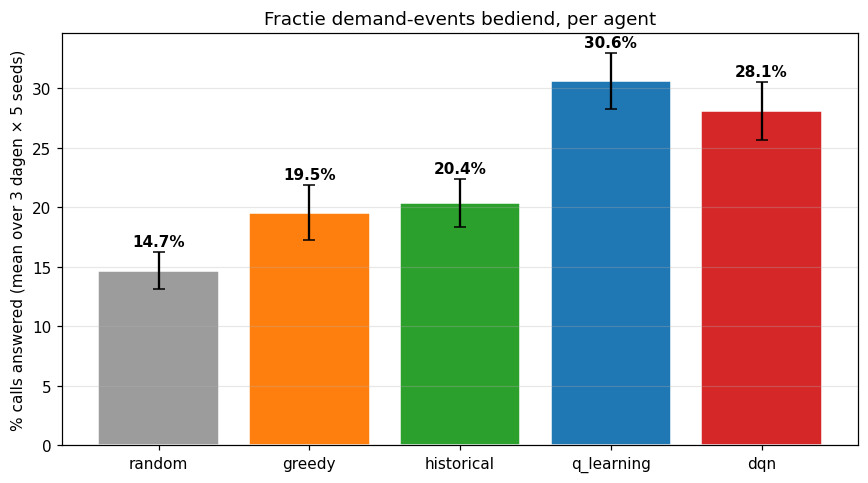

,mean,std
agent,,
random,14.673333,1.554274
greedy,19.544667,2.305710
historical,20.372667,1.988864
q_learning,30.617333,2.376782
dqn,28.088000,2.455627


In [2]:
df = pd.read_csv('results/eval_summary.csv')
by_agent = df.groupby('agent')['pct_answered'].agg(['mean', 'std']).reindex(AGENT_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(AGENT_ORDER))
bars = ax.bar(x, by_agent['mean'], yerr=by_agent['std'], capsize=4,
              color=[AGENT_COLORS[a] for a in AGENT_ORDER], edgecolor='white')
ax.set_xticks(x, AGENT_ORDER)
ax.set_ylabel('% calls answered (mean over 3 dagen × 5 seeds)')
ax.set_title('Fractie demand-events bediend, per agent')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(by_agent['mean'], by_agent['std'])):
    ax.annotate(f'{m:.1f}%', (i, m + s + 0.5), ha='center', fontsize=10, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'fig1_pct_answered.png', dpi=110)
plt.show()
by_agent

## Figuur 2 — Heatmap: agent coverage vs werkelijke vraag

Top-20 demand-zones × uur, voor 1 mei (feestdag, hoogste demand). Links: actuele demand. Rechts: Q-learning agent's van-aanwezigheid (cumul over 5 seeds).

In [3]:
from src.agents.q_learning import TabularQAgent, Q_TABLE_PATH
from src.env.dispatcher_env import DAY_START_HOUR, TIME_STEP_MINUTES, DispatcherEnv
from src.env.forecast_service import ForecastService

TARGET_DATE = date(2026, 5, 1)  # holiday — most demand
N_SEEDS_VIZ = 5

print('Loading forecaster...')
forecaster = ForecastService()
env = DispatcherEnv(date=TARGET_DATE, n_vans=15, seed=42, forecaster=forecaster)

# Demand grid (zone × hour) from features.parquet
features = pd.read_parquet('data/processed/features.parquet')
day_feat = features[features['timestamp'].dt.date == TARGET_DATE].copy()
demand_grid = day_feat.pivot_table(index='h3_cell', columns=day_feat['timestamp'].dt.hour,
                                   values='demand', aggfunc='sum', fill_value=0)
top_zones = demand_grid.sum(axis=1).sort_values(ascending=False).head(20).index.tolist()
demand_grid_top = demand_grid.loc[top_zones]
print(f'Top-20 demand zones, hour columns {sorted(demand_grid_top.columns.tolist())}')

Loading forecaster...


Top-20 demand zones, hour columns [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [4]:
# Aggregate Q-agent van-presence over 5 seeds for the same date
presence = pd.DataFrame(0, index=top_zones, columns=demand_grid_top.columns, dtype=int)
for seed in range(N_SEEDS_VIZ):
    agent = TabularQAgent.load(env, Q_TABLE_PATH)
    obs, _ = env.reset(seed=seed, options={'date': TARGET_DATE})
    agent.reset(seed=seed)
    terminated = truncated = False
    while not (terminated or truncated):
        action = agent.select_action(obs)
        h = env._time_minutes // 60
        for v in range(env.n_vans):
            cell = env.zones[action[v]]
            if cell in top_zones and h in presence.columns:
                presence.loc[cell, h] += 1
        obs, _, terminated, truncated, _ = env.step(action)
print(f'Aggregated van-presence shape: {presence.shape}, total cells visited: {presence.values.sum()}')

Aggregated van-presence shape: (20, 24), total cells visited: 1357


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
z_labels = [c[-6:] for c in top_zones]  # short cell ids

im0 = axes[0].imshow(demand_grid_top.values, aspect='auto', cmap='YlOrRd')
axes[0].set_yticks(range(len(top_zones)), z_labels, fontsize=8)
axes[0].set_xticks(range(len(demand_grid_top.columns)), demand_grid_top.columns)
axes[0].set_xlabel('Uur (UTC)')
axes[0].set_title('(a) Werkelijke demand per uur — top 20 zones, 1 mei')
plt.colorbar(im0, ax=axes[0], label='demand events')

im1 = axes[1].imshow(presence.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(presence.columns)), presence.columns)
axes[1].set_xlabel('Uur (UTC)')
axes[1].set_title('(b) Q-agent van-aanwezigheid (5 seeds)')
plt.colorbar(im1, ax=axes[1], label='van-step counts')

fig.suptitle('Coverage check: agent gaat naar de juiste zones?', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / 'fig2_coverage_heatmap.png', dpi=110)
plt.show()

C:\Users\ralph\AppData\Local\Temp\ipykernel_6932\3344392744.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figuur 3 — Tijdlijn: alle karren in beweging op 1 mei

Linker: zone-trajecten op de kaart (lat/lng) — kleur per van.
Rechter: per van een horizontale lijn van zone-changes over de dag (markers op moments waar de van wisselt).

In [6]:
# One episode of Q-agent for trajectory viz
agent = TabularQAgent.load(env, Q_TABLE_PATH)
obs, _ = env.reset(seed=0, options={'date': TARGET_DATE})
agent.reset(seed=0)
actions_history = []
terminated = truncated = False
while not (terminated or truncated):
    action = agent.select_action(obs)
    actions_history.append(action.copy())
    obs, _, terminated, truncated, _ = env.step(action)

# Per-van centroid trajectory
centroids = np.array([h3.cell_to_latlng(z) for z in env.zones])
n_steps = len(actions_history)
trajectories = np.zeros((env.n_vans, n_steps, 2))
for v in range(env.n_vans):
    for t in range(n_steps):
        trajectories[v, t] = centroids[actions_history[t][v]]
print(f'Trajectories shape: {trajectories.shape}')

Trajectories shape: (15, 66, 2)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) trajectories on map (lng vs lat)
ax = axes[0]
cmap = plt.cm.tab20
for v in range(env.n_vans):
    lats, lngs = trajectories[v, :, 0], trajectories[v, :, 1]
    ax.plot(lngs, lats, color=cmap(v % 20), alpha=0.7, linewidth=1.0)
    ax.scatter(lngs, lats, color=cmap(v % 20), s=8, alpha=0.55, edgecolor='none')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('(a) Van-trajecten op de kaart — Q-agent, 1 mei')
ax.grid(True, alpha=0.3)

# (b) zone-change strip per van
ax = axes[1]
for v in range(env.n_vans):
    times = []
    for t in range(1, n_steps):
        if actions_history[t][v] != actions_history[t-1][v]:
            times.append(DAY_START_HOUR + t * TIME_STEP_MINUTES / 60.0)
    ax.scatter(times, [v] * len(times), s=20, color=cmap(v % 20), alpha=0.7)
    ax.hlines(v, xmin=DAY_START_HOUR, xmax=DAY_START_HOUR + n_steps * TIME_STEP_MINUTES / 60.0,
              color='lightgrey', linewidth=0.5, alpha=0.4)
ax.set_yticks(range(env.n_vans), [f'kar {v+1}' for v in range(env.n_vans)], fontsize=8)
ax.set_xlabel('Uur (UTC)')
ax.set_title('(b) Zone-wissels per kar — markers op moment van verplaatsing')
ax.grid(True, axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES / 'fig3_van_movements.png', dpi=110)
plt.show()

C:\Users\ralph\AppData\Local\Temp\ipykernel_6932\1281820238.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figuur 4 — Reward curves per agent tijdens training

Q-learning (60 episodes, hertraind hier voor history) + DQN (500 episodes, uit CSV-log). Random/greedy/historical hebben geen training-curves; we plotten hun mean test-reward als horizontale baselines.

In [8]:
# Re-train Q briefly to capture per-episode reward history (q_table.pkl doesn't store it)
from src.agents.q_learning import TabularQAgent
import time
agent_q = TabularQAgent(env)
t0 = time.time()
q_history = agent_q.train(dates=[date(2026, 4, 30), date(2026, 5, 1)], n_episodes=60)
print(f'Q-training: {len(q_history)} episodes in {time.time()-t0:.0f}s')

Q-training: 60 episodes in 18s


In [9]:
dqn_log = pd.read_csv('models/dqn_train_log.csv')

# Baseline lines: mean test sales per non-trained agent (from eval_summary)
baselines = df.groupby('agent')['n_sales_answered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Q-learning
ax = axes[0]
x_q = np.arange(1, len(q_history) + 1)
ax.plot(x_q, q_history, color=AGENT_COLORS['q_learning'], marker='.', linewidth=0.5, alpha=0.4)
w = max(3, len(q_history) // 10)
rolling = np.convolve(q_history, np.ones(w)/w, mode='valid')
ax.plot(np.arange(w, w+len(rolling)), rolling, color=AGENT_COLORS['q_learning'], linewidth=2, label=f'Q-learning rolling mean (w={w})')
for name in ['random', 'greedy', 'historical']:
    ax.axhline(baselines[name], color=AGENT_COLORS[name], linestyle='--', linewidth=1, label=f'{name} (test mean)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward (= sales)')
ax.set_title('(a) Q-learning training (60 episodes)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower right')

# (b) DQN
ax = axes[1]
ax.plot(dqn_log['episode'], dqn_log['reward'], color=AGENT_COLORS['dqn'], marker='.', linewidth=0.4, alpha=0.3)
w = max(10, len(dqn_log) // 20)
rolling = np.convolve(dqn_log['reward'], np.ones(w)/w, mode='valid')
ax.plot(np.arange(w, w+len(rolling)), rolling, color=AGENT_COLORS['dqn'], linewidth=2, label=f'DQN rolling mean (w={w})')
for name in ['random', 'greedy', 'historical']:
    ax.axhline(baselines[name], color=AGENT_COLORS[name], linestyle='--', linewidth=1, label=f'{name} (test mean)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward (= sales)')
ax.set_title('(b) DQN training (500 episodes)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Reward per episode tijdens training — getrainde agents vs niet-getrainde baselines', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / 'fig4_reward_curves.png', dpi=110)
plt.show()

C:\Users\ralph\AppData\Local\Temp\ipykernel_6932\4038398071.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Output

Vier figuren in `reports/figures/`:
- `fig1_pct_answered.png` — DoD-bar.
- `fig2_coverage_heatmap.png` — coverage check tegen actuele vraag.
- `fig3_van_movements.png` — kaart-trajecten + zone-change strip per kar.
- `fig4_reward_curves.png` — Q + DQN training met baseline-lijnen.

Klaar voor opname in fiche/defense.